In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import spacy
import glob
from constants import BASE_PATH
import json
import pandas as pd
import text_cleaning as tc
from tqdm.auto import tqdm
from collections import Counter

In [3]:
!python -m spacy download es_core_news_sm

Checked 1 package in 80ms
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


# Approach
Now use the GPT-cleaned documents to build mappings and other information to fix the OCR errors in the entire corpus

# Build Resources

In [4]:
json_paths  = glob.glob(f'{BASE_PATH}**/processed_gpt.json', recursive=True)

In [5]:
len(json_paths)

34

In [13]:
# nlp = spacy.load("es_core_news_sm")
nlp = spacy.blank("es")

In [ ]:
text_pairs = []
for path in json_paths:
    print(path)
    with open(path, 'r') as f:
        d = json.load(f)
    
    for t in d['gpt_fixed']:
        try:
            text_pairs.append({
                'raw_text': t['raw_text'],
                'gpt_fixed_conservative': t['gpt_fixed_conservative']
            })
        except:
            continue

In [15]:
len(text_pairs)

3961

In [16]:
phrase_counter, word_pair_counter, word_raw_totals = tc.mine_patches_and_words(
    text_pairs,
    nlp=nlp,
    phrase_min_span=2,
    phrase_max_span=5,
    include_newlines_in_phrases=False,
    lowercase_word_key=False,
)


In [17]:
phrase_patches = tc.finalize_phrase_patches(phrase_counter, min_count=2)
word_repls = tc.finalize_word_replacements(word_pair_counter, word_raw_totals, min_count=2, min_precision=0.9)
word_map = tc.build_word_map(word_repls)

In [18]:
patch_index = tc.build_phrase_patch_index(phrase_patches)

# Build SymSpell Dict

In [20]:
from wordfreq import top_n_list, zipf_frequency
from symspellpy import SymSpell, Verbosity

In [21]:

def spanish_prior_words(min_zipf=3.0, max_words=200_000):
    """
    Return a set of common Spanish words that may not appear in corpus.
    min_zipf ≈ 3.0 keeps reasonably common words.
    """
    words = []
    for w in top_n_list("es", max_words):
        if zipf_frequency(w, "es") >= min_zipf:
            words.append(w)
    return words

In [22]:
json_paths  = glob.glob(f'{BASE_PATH}**/processed.json', recursive=True)
fixed_counts = Counter()
raw_counts = Counter()

In [23]:
for path in tqdm(json_paths):
    # print(path)
    with open(path, 'r') as f:
        try:
            d = json.load(f)
            for t in d['text_blocks_raw']:
                if len(t['text']) > 20:
                    raw_counts.update(tc.simple_tok(tc.preclean_ocr_text(t['text'].lower())))
                    fixed_counts.update(tc.simple_tok((t['text'].lower())))
        except json.JSONDecodeError as e:
                # Handle the specific error if decoding fails
                print("Error: Unable to decode JSON.")
                print("Details:", e)


100%|█████████████████████████████████████████████████████████████| 163765/163765 [13:57<00:00, 195.49it/s]


In [24]:
total_word_count = sum(raw_counts.values())
print(total_word_count)

290885973


In [25]:
final_counts = Counter()

for w, c in raw_counts.items():
    if len(w) < 3:
        continue
    if any(ch.isdigit() for ch in w):
        final_counts[w] += max(1, c // 10)
    else:
        final_counts[w] += min(c, 50)

for w, c in fixed_counts.items():
    if len(w) < 3:
        continue
    boost = min(c * 5, 500)
    final_counts[w] += boost

# reward agreement between raw and fixed
for w in final_counts:
    final_counts[w] += min(raw_counts.get(w, 0), fixed_counts.get(w, 0)) * 2

In [26]:
for w in spanish_prior_words(min_zipf=2.0):
    if w not in final_counts:
        # convert Zipf to a small pseudo-count
        z = zipf_frequency(w, "es")
        final_counts[w] += max(1, int(10 ** (z - 4)))

In [27]:
min_count=10
with open('data/resources/sysmspell_dict.txt', "w", encoding="utf8") as f:
    for w, c in final_counts.items():
        if c >= min_count:
            f.write(f"{w}\t{c}\n")

## Build Vocab

In [28]:
vocab_set = tc.build_vocab_set(fixed_counts, raw_counts)
for w in spanish_prior_words(min_zipf=4.0):
    vocab_set.add(w)

# Fix OCR Text

## Load Symspell

In [29]:
symspell = SymSpell(max_dictionary_edit_distance=2, prefix_length=7)

symspell.load_dictionary(
    "./data/resources/sysmspell_dict.txt",
    term_index=0,
    count_index=1,
    separator="\t",
    encoding="utf8"
)

True

## Token fix loop

In [30]:
from collections import defaultdict

In [31]:
CONFUSIONS = {
    '(jibar': 'Gibar'
}

In [32]:
results = []
for text_pair in text_pairs:
    doc = nlp(text_pair['raw_text']) 
    fixed = tc.fix_ocr_doc(
        doc,
        nlp=nlp,
        patch_index=patch_index,
        symspell=symspell,
        vocab_set=vocab_set,
        word_map=word_map,
        use_word_map=False,          # toggle this to test harm/help
        min_score_gain=0.8,
        confusion_pairs=CONFUSIONS,  # optional
    )
    res = tc.evaluate_ocr_fix(doc, nlp(text_pair['gpt_fixed_conservative']), fixed) 
    results.append(res)
    print(res['damage_rate'], res['edit_precision'], res['edit_recall'])

0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.3333333333333333 0.0 1.0
0.5 0.0 1.0
1.0 0.0 1.0
0.17857142857142858 0.0 1.0
0.0 1.0 1.0
0.42105263157894735 0.0 1.0
0.21052631578947367 0.0 1.0
0.3333333333333333 0.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.13513513513513514 0.0 1.0
0.2222222222222222 0.0 1.0
0.06666666666666667 0.0 1.0
0.125 0.0 1.0
0.10526315789473684 0.0 1.0
0.0 1.0 1.0
0.21153846153846154 0.0 1.0
0.05555555555555555 0.0 1.0
0.2 0.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.09090909090909091 0.0 1.0
0.25 0.0 1.0
0.36363636363636365 0.0 1.0
0.3333333333333333 0.0 1.0
0.16279069767441862 0.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.1111111111111111 0.0 1.0
0.2857142857142857 0.0 1.0
0.2 0.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.23076923076923078 0.0 1.0
0.14705882352941177 0.0 1.0
0.11764705882352941 0.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.16666666666666666 0.0 1.0
0.0 1.0 1.0
0.1 0.0 1.0
0.03225806451612903 0.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.2857142857142857 0.0 1.0
0.0 1.0 1.0


<Axes: ylabel='Frequency'>

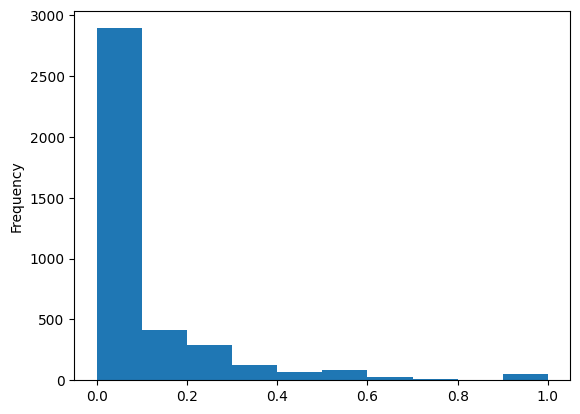

In [36]:
results_df = pd.DataFrame(results)
results_df['damage_rate'].plot.hist()

<Axes: ylabel='Frequency'>

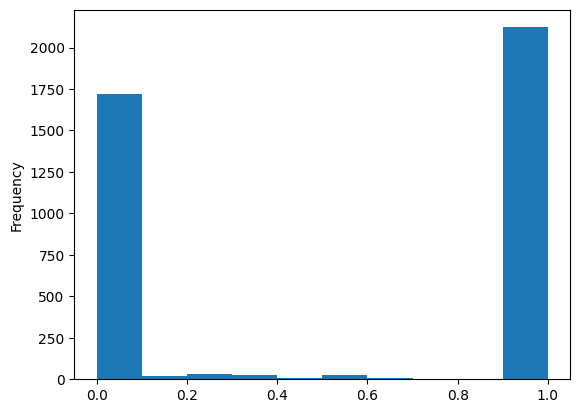

In [37]:
results_df = pd.DataFrame(results)
results_df['edit_precision'].plot.hist()

# Run on all text

In [6]:
json_paths  = glob.glob(f'{BASE_PATH}**/processed.json', recursive=True)
processed_json_paths  = [f.replace('cleaned', 'processed') for f in glob.glob(f'{BASE_PATH}**/cleaned.json', recursive=True)]

In [38]:
len(json_paths), len(processed_json_paths), len(processed_json_paths)/len(json_paths)

(163765, 134568, 0.8217140414618508)

In [43]:
for path in tqdm(json_paths):
    if path in processed_json_paths:
        continue
    try:
        with open(path, 'r') as f:
            d = json.load(f)
            cleaned = []
            for text in d['text_blocks_raw']:
                doc = nlp(text['text'].lower().replace('(jibar', 'gibar')) 
                fixed = tc.fix_ocr_doc(
                    doc,
                    nlp=nlp,
                    patch_index=patch_index,
                    symspell=symspell,
                    vocab_set=vocab_set,
                    word_map=word_map,
                    use_word_map=False,          # toggle this to test harm/help
                    min_score_gain=0.8,
                    confusion_pairs=CONFUSIONS,  # optional
                )
                c = text.copy()
                c['text'] = fixed.text
                cleaned.append(c)
                d['text_blocks_cleaned'] = cleaned
            with open(path.replace('processed.json', 'cleaned.json'), 'w') as json_file:
                json.dump(d, json_file)
    except:
        print("Error", path)
        break

100%|████████████████████████████████████████████████████████████| 163765/163765 [1:00:03<00:00, 45.44it/s]
